The steady state covection-diffusion governing equation can be derived from the geenral transport equation for property $\phi$ as below.

$$ div(\rho.u.ϕ) = div(\Gamma . grad ϕ ) + S_{\phi} $$

In the absence of sources and for a 1-d flow field, u.

$$ \frac{d(\rho u \phi)}{dx} = \frac{d}{dx} \left( \Gamma \frac{d \phi}{dx} \right) $$

Integration of both the equations over control volume gives the following.

$$ ∫_{cv} \frac{d(\rho u \phi)}{dx} = ∫_{cv} \frac{d}{dx} \left( \Gamma \frac{d \phi}{dx} \right) $$

$$ (\rho.u.ϕ)_e - (\rho.u.ϕ)_w = \left( \Gamma A \frac{d \phi}{dx} \right)_e -  \left( \Gamma A \frac{d \phi}{dx} \right)_w $$


For a general node P, the equation is as below.

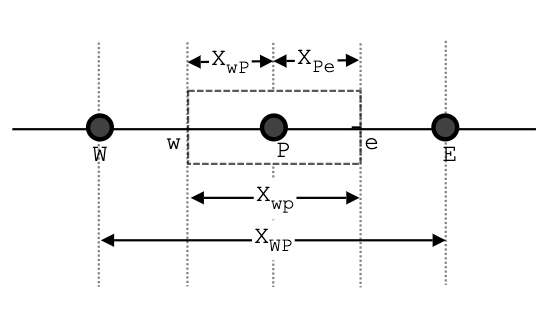

Replace the following for ease of notation.

$$ F = (\rho u) ; D = \frac{\Gamma}{\delta x} $$

$$ F_e \phi_e - F_w \phi_w = D_e ( \phi_E - \phi_P ) - D_w ( \phi_P - \phi_W )  $$

Using central differencing mechanism,

$$\phi_e = \frac{\phi_E + \phi_P}{2} ; \phi_w = \frac{\phi_P + \phi_W}{2} $$

Substituting in the equation above

$$ F_e \left( \frac{\phi_E + \phi_P}{2} \right) - F_w \left( \frac{\phi_W + \phi_P}{2} \right) = D_e ( \phi_E - \phi_P ) - D_w ( \phi_P - \phi_W )  $$

$$ \left[ \left( D_e + \frac{F_e}{2} \right) + \left( D_w - \frac{F_w}{2} \right) \right] \phi_P = \left( D_e - \frac{F_e}{2} \right) \phi_E - \left( D_w + \frac{F_w}{2} \right) \phi_W  $$

$$ \left[ \left( D_e - \frac{F_e}{2} \right) + \left( D_w + \frac{F_w}{2} \right) + (F_e - F_w) \right] \phi_P = \left( D_e - \frac{F_e}{2} \right) \phi_E - \left( D_w + \frac{F_w}{2} \right) \phi_W  $$

$$ \left[ a_E + a_W + (F_e - F_w) \right] \phi_P = a_E \phi_E - a_W \phi_W  $$


For boundary condition to the left, $\phi_A = \phi_w = 1 $

$$ F_e \left( \frac{\phi_E + \phi_P}{2} \right) - F_A \phi_A = D_e ( \phi_E - \phi_P ) - D_A ( \phi_P - \phi_A )  $$

where $$D_A = D_B = \frac{\Gamma}{\delta X_{wP}} = \frac{\Gamma}{\delta x/2}= 2*\frac{\Gamma}{\delta x} = 2D $$

where $$F_A = F_B = F$$

$$ F_e \left( \frac{\phi_E + \phi_P}{2} \right) - F_A \phi_A = D_e ( \phi_E - \phi_P ) - 2D ( \phi_P - \phi_A )  $$

$$ F_e \left( \frac{\phi_P}{2} \right) - F_A \phi_A = \left(D_e - \frac{F_e}{2}\right)\phi_E - D_e \phi_P - 2D ( \phi_P - \phi_A )  $$

$$ \left(D_e + 2D + \frac{F_e}{2} \right) \phi_P - F_A \phi_A = \left(D_e - \frac{F_e}{2}\right)\phi_E + 2D \phi_A  $$

$$ \left(D_e + 2D + \frac{F_e}{2} \right) \phi_P = \left(D_e - \frac{F_e}{2}\right)\phi_E + (2D + F_A) \phi_A  $$

$$ \left( 3D + \frac{F}{2} \right) \phi_P = \left(D - \frac{F}{2}\right)\phi_E + (2D + F) \phi_A  $$


For boundary condition to the right, $\phi_B = \phi_e = 0 $

$$ F_B \phi_B - F_w \left( \frac{\phi_W + \phi_P}{2} \right) = D_e ( \phi_B - \phi_P ) - D_w ( \phi_P - \phi_W )  $$

$$ F \phi_B - F \left( \frac{\phi_W + \phi_P}{2} \right) = 2D ( \phi_B - \phi_P ) - D ( \phi_P - \phi_W )  $$

$$ - F \left( \frac{\phi_W + \phi_P}{2} \right) = (2D - F)\phi_B - 2D \phi_P - D ( \phi_P - \phi_W )  $$

$$ \left( D - \frac{F}{2} \right) \phi_P - \frac{F \phi_W}{2}  = (2D - F)\phi_B - 2D \phi_P + D \phi_W $$

$$ \left( 3D - \frac{F}{2} \right) \phi_P - \frac{F \phi_W}{2}  = D \phi_W + (2D - F)\phi_B $$

$$ \left( 3D - \frac{F}{2} \right) \phi_P  = \left(D + \frac{F}{2} \right) \phi_W + (2D - F)\phi_B $$

In [60]:
import numpy as np

def numerical_solution(u, rho, Gamma, dx, F, D, num_nodes):
  # 1. Initialize a 5x5 NumPy array A and a 5x1 NumPy array B with zeros.
  A = np.zeros((num_nodes, num_nodes))
  B = np.zeros(num_nodes)

  # 2. Define the coefficients for the equations
  D_minus_F_half = D - F/2
  D_plus_F_half = D + F/2
  TwoD = 2 * D
  TwoD_plus_F = 2 * D + F
  ThreeD_plus_F_half = 3 * D + F/2
  ThreeD_minus_F_half = 3 * D - F/2

  # 3. Apply the left boundary condition for the first node (row 0)
  A[0, 0] = ThreeD_plus_F_half
  A[0, 1] = -D_minus_F_half
  B[0] = TwoD_plus_F

  # 4. Loop through the internal nodes
  for i in range(1, num_nodes - 1):
      A[i, i-1] = -D_plus_F_half
      A[i, i] = TwoD
      A[i, i+1] = -D_minus_F_half

  # 5. Apply the right boundary condition for the last node
  A[num_nodes-1, num_nodes-2] = -D_plus_F_half
  A[num_nodes-1, num_nodes-1] = ThreeD_minus_F_half

  # 6. Print the constructed A matrix and B vector.
  print("Constructed A matrix:")
  print(A)
  print("\nConstructed B vector:")
  print(B)

  phi = np.linalg.solve(A, B)

  return phi

In [61]:
u = 0.1  # m/s
rho = 1.0
Gamma = 0.1
dx = 0.2 # m (delta x)
L = 1
F = rho * u
D = Gamma / dx

num_nodes = 5

phi = numerical_solution(u, rho, Gamma, dx, F, D, num_nodes)

print("Solution for phi (X):")
print(phi)

Constructed A matrix:
[[ 1.55 -0.45  0.    0.    0.  ]
 [-0.55  1.   -0.45  0.    0.  ]
 [ 0.   -0.55  1.   -0.45  0.  ]
 [ 0.    0.   -0.55  1.   -0.45]
 [ 0.    0.    0.   -0.55  1.45]]

Constructed B vector:
[1.1 0.  0.  0.  0. ]
Solution for phi (X):
[0.94210996 0.80060097 0.62764554 0.41625556 0.15789004]


In [62]:
"""
Calculates the analytical solution for the 1-D steady-state convection-diffusion equation.

Args:
    x (float or np.array): Position(s) at which to calculate phi.
    u_val (float): Velocity.
    L_val (float): Length of the domain.
    rho_val (float): Density.
    Gamma_val (float): Diffusion coefficient.

Returns:
    float or np.array: The analytical solution for phi at position x.
"""
def phi_analytical(x, u_val, L_val, rho_val, Gamma_val):
    Pe = (rho_val * u_val * L_val) / Gamma_val
    phi_x = (np.exp(Pe * x / L_val) - np.exp(Pe)) / (1 - np.exp(Pe))
    return phi_x

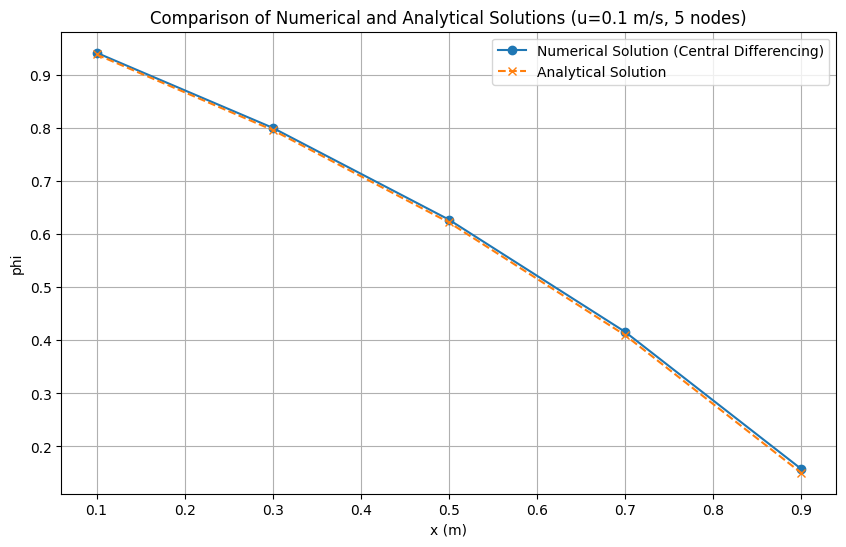

In [63]:
import matplotlib.pyplot as plt

# Generate x-coordinates for the numerical solution (nodes)
x_numerical = np.linspace(dx/2, L - dx/2, num_nodes)

# Calculate analytical solution at the numerical node positions
phi_analytical_values = phi_analytical(x_numerical, u, L, rho, Gamma)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_numerical, phi, 'o-', label='Numerical Solution (Central Differencing)')
plt.plot(x_numerical, phi_analytical_values, 'x--', label='Analytical Solution')

plt.xlabel('x (m)')
plt.ylabel('phi')
plt.title('Comparison of Numerical and Analytical Solutions (u=0.1 m/s, 5 nodes)')
plt.grid(True)
plt.legend()
plt.show()

In [64]:
u = 2.5  # m/s
rho = 1.0
Gamma = 0.1
dx = 0.2 # m (delta x)

F = rho * u
D = Gamma / dx

num_nodes = 5

phi = numerical_solution(u, rho, Gamma, dx, F, D, num_nodes)

print("Solution for phi (X):")
print(phi)

Constructed A matrix:
[[ 2.75  0.75  0.    0.    0.  ]
 [-1.75  1.    0.75  0.    0.  ]
 [ 0.   -1.75  1.    0.75  0.  ]
 [ 0.    0.   -1.75  1.    0.75]
 [ 0.    0.    0.   -1.75  0.25]]

Constructed B vector:
[3.5 0.  0.  0.  0. ]
Solution for phi (X):
[1.0356305  0.86935484 1.25733138 0.35205279 2.4643695 ]


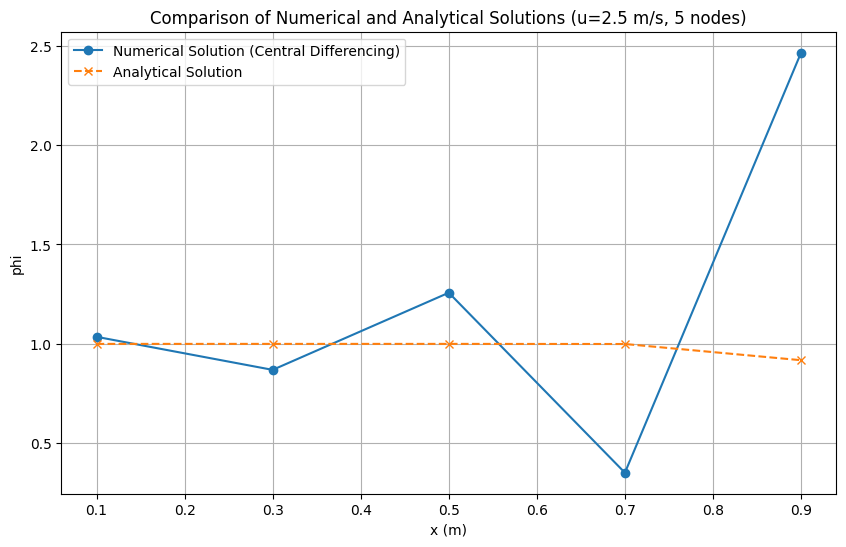

In [65]:
# Generate x-coordinates for the numerical solution (nodes)
x_numerical = np.linspace(dx/2, L - dx/2, num_nodes)

# Calculate analytical solution at the numerical node positions
phi_analytical_values = phi_analytical(x_numerical, u, L, rho, Gamma)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_numerical, phi, 'o-', label='Numerical Solution (Central Differencing)')
plt.plot(x_numerical, phi_analytical_values, 'x--', label='Analytical Solution')

plt.xlabel('x (m)')
plt.ylabel('phi')
plt.title('Comparison of Numerical and Analytical Solutions (u=2.5 m/s, 5 nodes)')
plt.grid(True)
plt.legend()
plt.show()

In [66]:
u = 2.5  # m/s
rho = 1.0
Gamma = 0.1
dx = 0.05 # m (delta x)

F = rho * u
D = Gamma / dx

num_nodes = 20

phi = numerical_solution(u, rho, Gamma, dx, F, D, num_nodes)

print("Solution for phi (X):")
print(phi)

Constructed A matrix:
[[ 7.25 -0.75  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    0.  ]
 [-3.25  4.   -0.75  0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.   -3.25  4.   -0.75  0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.   -3.25  4.   -0.75  0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.   -3.25  4.   -0.75  0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.   -3.25  4.   -0.75  0.    0.    0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.   -3.25  4.   -0.75  0.    0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.   -3.25  4.   -0.75  0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    

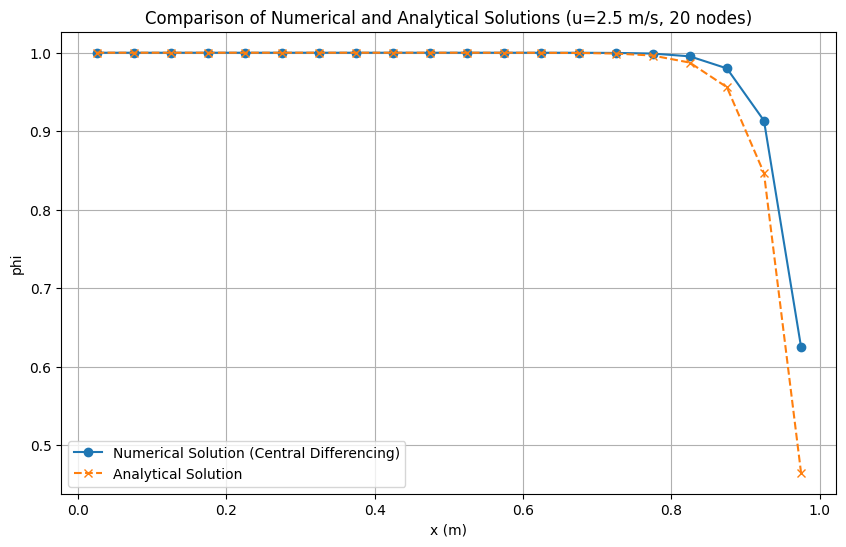

In [67]:
# Generate x-coordinates for the numerical solution (nodes)
x_numerical = np.linspace(dx/2, L - dx/2, num_nodes)

# Calculate analytical solution at the numerical node positions
phi_analytical_values = phi_analytical(x_numerical, u, L, rho, Gamma)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_numerical, phi, 'o-', label='Numerical Solution (Central Differencing)')
plt.plot(x_numerical, phi_analytical_values, 'x--', label='Analytical Solution')

plt.xlabel('x (m)')
plt.ylabel('phi')
plt.title('Comparison of Numerical and Analytical Solutions (u=2.5 m/s, 20 nodes)')
plt.grid(True)
plt.legend()
plt.show()